In [5]:
!pip install ultralytics

In [7]:
from ultralytics import YOLO
model = YOLO('yolo26n.pt')


image 1/1 /yolo_test_image.jpg: 448x640 1 person, 5 cars, 2 trucks, 1 handbag, 333.9ms
Speed: 12.1ms preprocess, 333.9ms inference, 6.2ms postprocess per image at shape (1, 3, 448, 640)


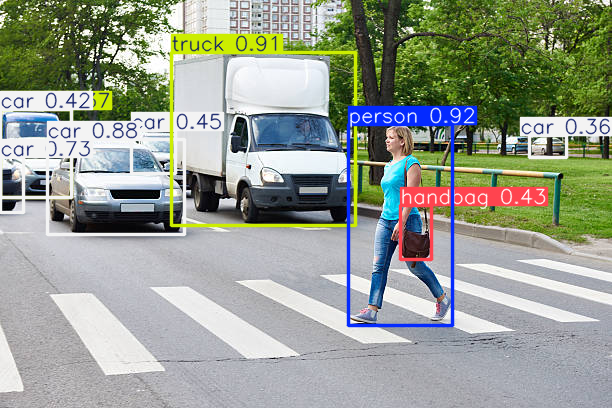

In [9]:
image_path = "/yolo_test_image.jpg"

results = model(image_path)

results[0].show()

In [11]:
results[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

In [23]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_results(image_path, results):
    img = Image.open(image_path)
    plt.figure(figsize=(12,8))
    plt.imshow(img)

    ax = plt.gca()

    # plot each bounding box
    for box in results[0].boxes:
      xyxy= box.xyxy[0].cpu() if box.xyxy[0].is_cuda else box.xyxy[0]
      x1, y1, x2, y2 = xyxy.numpy()

      rec = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1,facecolor='none', edgecolor='r')
      ax.add_patch(rec)


      cls= int(box.cls.cpu().numpy()[0] if box.cls[0].is_cuda else box.cls.numpy()[0])
      conf = float(box.conf.cpu().numpy()[0] if box.conf[0].is_cuda else box.conf.numpy()[0])
      label = f'{results[0].names[cls] } {conf:.2f}'
      plt.text(x1,y1, label, color='white', fontsize=10, backgroundcolor='red')

    plt.axis('off')
    plt.show()




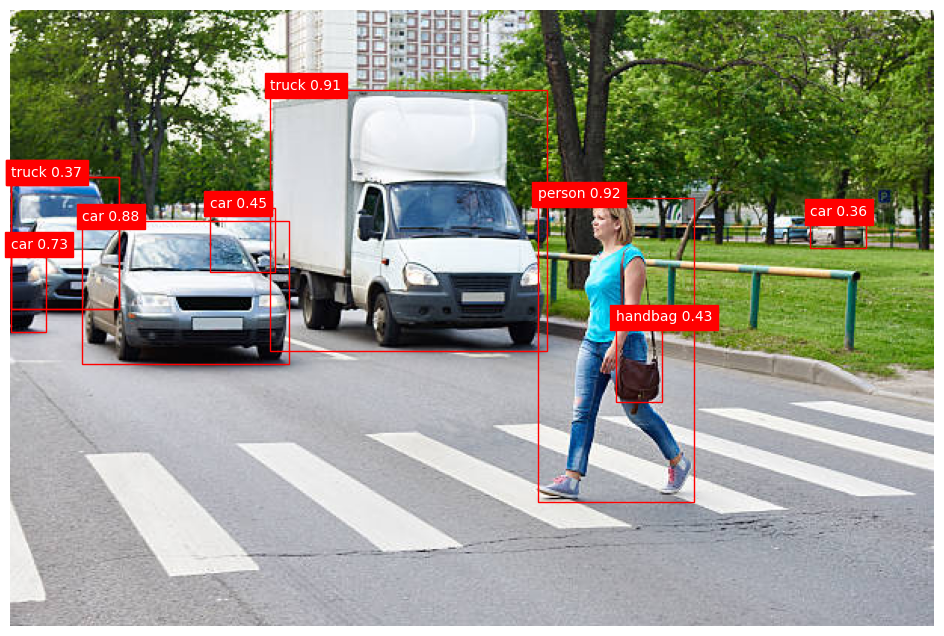

In [24]:
plot_results(image_path, results)